# Workshop 4 example solution: Genetic Programming

In [ ]:
import operator
import math
import random
import pygraphviz as pgv
import numpy

from deap import algorithms
from deap import base
from deap import creator
from deap import tools
from deap import gp

Remember that when using genetic programming, you need to make sure that your functions are viable. GP does not know not to divide by zero, so you need to define a protected division for it.

In [ ]:
def protectedDiv(num, denom):
    try:
        return num / denom
    except ZeroDivisionError:
        return 1

Our individual will be a function that we will pass one value (x) to. As such, you need to define a primitive set that takes in 1 value. You would increase this if you wanted to pass more values, and have it at zero if your individual does not receive any arguments when it is executed.

In [ ]:
pset = gp.PrimitiveSet("MAIN", 1)

By default input arguments are termed ARG0, ARG2 ... ARGi. Let's rename ARG0 to x.

In [ ]:
pset.renameArguments(ARG0='x')

We now register our functions and terminals. We would normally not know the function in advance, and might want to start with a limited set and then expand if needed.

In [ ]:
pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(protectedDiv, 2)
pset.addPrimitive(operator.neg, 1)
#pset.addPrimitive(math.sin, 1)
#pset.addPrimitive(math.cos, 1)

Next we add an **ephemeral Constant**. The value of the constant is randomly initialised and then kept constant for a particular individual tree, but will differ from one Tree to another.

In [ ]:
pset.addEphemeralConstant("rand101", lambda: random.randint(-1,1))

Note that we have usef lambda to create an anonymous function on the fly. This is so that we can define the arguments to randint to constrain it between -1 and 1.

In [ ]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

We are using genHalfAndHalf() to crete the initial population of trees. Note the min_ and max_ bounds - the initial population will be very small trees.

In [ ]:
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=2)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

Below we are registering standard tournament selection. To see how we might use double tournament selection, look at `EVAC-Workshop-4a-example.ipynb`.

For mutation, we are using `gp.mutUniform()`. This is different from the standard `mutUniform()`. It randomly selects a point in the tree (individual), then replaces the subtree at that point by an expression generated using method `expr()`. In this case, we have used `gp.genHalfAndHalf()` to generate the new subtree.

In [ ]:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genHalfAndHalf, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

You might consider adding some limits on the height of any generated branch. However, you will see that evolution works much better whenless constrained (but other problems emerge):

In [ ]:
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=6))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=6))

## Evaluation function

Provided below is an example of the evaluation function. Whereas in the walkthrough I showed you how to fit to data, here, we are doing the same thing, but we are generating the data on-the-fly using the data-generating function that we have decided to use. We can change that function to be anything we want, and even add randomness to it if we like. We pass the individual to the evaluation function, just as we have always done previously. But we also pass the inputs that we want to evaluate. I choose to pass in a big range of points that are systematically generated, but you could chose to pass random x values if you like. This data-generating function that we are fitting to could be changed to any other function, depending on your problem.

In [ ]:
def evalSymbReg(individual, points):
    func = toolbox.compile(expr=individual)
    sqerrors = ((func(x) - (x**4 - x**3 - x**2 - x))**2 for x in points)
    return math.fsum(sqerrors),

In [ ]:
toolbox.register("evaluate", evalSymbReg, points=[x/10. for x in range(-100,100)])

## Register some stats

In [ ]:
stats_fit = tools.Statistics(lambda ind: ind.fitness.values)
stats_size = tools.Statistics(len)
mstats = tools.MultiStatistics(fitness=stats_fit, size=stats_size)
mstats.register("avg", numpy.mean)
mstats.register("std", numpy.std)
mstats.register("min", numpy.min)
mstats.register("max", numpy.max)

## Main algorithm

Before, you've always seen the full algorithm coded out. You can do the same here, but for brevity in this walkthrough I have used eaSimple.

In [ ]:
pop = toolbox.population(n=50)
hof = tools.HallOfFame(1)

pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.1, ngen=100, stats=mstats,
                                   halloffame=hof, verbose=True)

   	      	                                  fitness                                  	                      size                     
   	      	---------------------------------------------------------------------------	-----------------------------------------------
gen	nevals	avg        	gen	max        	min        	nevals	std        	avg 	gen	max	min	nevals	std    
0  	50    	2.21742e+09	0  	2.27314e+09	2.15901e+09	50    	1.38845e+07	4.16	0  	7  	2  	50    	1.75909
1  	25    	2.20816e+09	1  	2.27395e+09	2.10465e+09	25    	2.75687e+07	4.24	1  	8  	2  	25    	1.82822
2  	33    	2.20013e+09	2  	2.27214e+09	2.10266e+09	33    	3.56585e+07	4.72	2  	9  	2  	33    	1.89779
3  	28    	2.1865e+09 	3  	2.21799e+09	1.99632e+09	28    	5.0006e+07 	5.5 	3  	13 	1  	28    	2.36854
4  	30    	2.17217e+09	4  	2.21823e+09	1.99632e+09	30    	6.37016e+07	5.42	4  	9  	2  	30    	2.13626
5  	25    	2.16899e+09	5  	2.21823e+09	1.99632e+09	25    	6.5327e+07 	5.38	5  	14 	1  	25    	2.49712
6  	26    	2.151

86 	26    	2.66246e+08	86 	9.39657e+08	2.04816e+08	26    	1.49437e+08	35.12	86 	39 	23 	26    	2.78309
87 	32    	3.18159e+08	87 	2.22661e+09	2.04816e+08	32    	3.56996e+08	34.74	87 	41 	19 	32    	3.96389
88 	33    	3.46091e+08	88 	2.21539e+09	2.04816e+08	33    	3.89836e+08	34.46	88 	41 	1  	33    	6.09659
89 	32    	2.60065e+08	89 	1.08623e+09	2.04232e+08	32    	1.59286e+08	35.88	89 	41 	23 	32    	3.12819
90 	34    	3.07564e+08	90 	1.78927e+09	2.04232e+08	34    	2.72207e+08	35.04	90 	39 	17 	34    	3.88824
91 	24    	2.60965e+08	91 	8.05005e+08	2.04816e+08	24    	1.17169e+08	36.36	91 	45 	27 	24    	2.75507
92 	26    	2.92673e+08	92 	8.05005e+08	2.04816e+08	26    	1.56878e+08	36.26	92 	43 	29 	26    	2.84823
93 	23    	3.36539e+08	93 	2.22661e+09	2.04816e+08	23    	3.60944e+08	35.66	93 	43 	19 	23    	4.13091
94 	25    	2.84366e+08	94 	2.21618e+09	2.04816e+08	25    	2.92214e+08	36.46	94 	42 	21 	25    	3.07382
95 	25    	2.41051e+08	95 	5.76567e+08	2.04816e+08	25    	7.4015e+07 	36.

## Basic plots

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

gen = log.chapters['fitness'].select("gen")
_min = log.chapters['fitness'].select("min")
_max = log.chapters['fitness'].select("max")
avgs = log.chapters['fitness'].select("avg")
stds = log.chapters['fitness'].select("std")

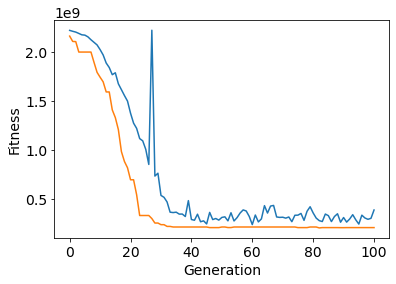

In [ ]:
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)

fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, avgs)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness")

line2 = ax1.plot(gen, _min)
#line3 = ax1.plot(gen, _max)

## Let's examine our best individual

In [ ]:
indv = tools.selBest(pop, 1)[0]
print(indv)

mul(add(add(add(add(add(x, x), x), x), x), add(add(x, add(add(x, x), x)), -1)), add(add(add(x, add(add(x, x), x)), -1), add(x, add(add(x, x), x))))


In [ ]:
nodes, edges, labels = gp.graph(indv)

tree = pgv.AGraph()
tree.add_nodes_from(nodes)
tree.add_edges_from(edges)
tree.layout(prog="dot")

for i in nodes:
    n = tree.get_node(i)
    n.attr["label"] = labels[i]

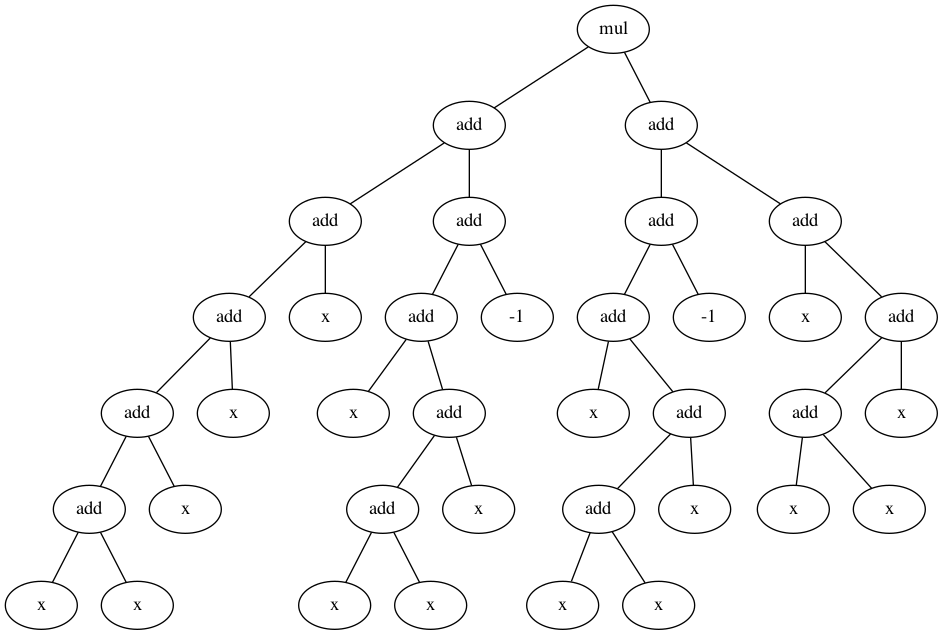

In [ ]:
from IPython.display import Image

treePlot = tree.draw(format='png', prog='dot')
Image(treePlot)

In [ ]:
toolbox.evaluate(indv)

(204816018.17216662,)

In [ ]:
indvFunction = toolbox.compile(expr=indv)
desired = lambda x : x**4 - x**3 - x**2 - x

Let's try an out-of-sample number

In [ ]:
points = [x for x in range(-10,11)]
points

[-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
list(map(indvFunction,points))

[7371,
 5986,
 4745,
 3648,
 2695,
 1886,
 1221,
 700,
 323,
 90,
 1,
 56,
 255,
 598,
 1085,
 1716,
 2491,
 3410,
 4473,
 5680,
 7031]

In [ ]:
list(map(desired,points))

[10910,
 7218,
 4552,
 2702,
 1482,
 730,
 308,
 102,
 22,
 2,
 0,
 -2,
 2,
 42,
 172,
 470,
 1038,
 2002,
 3512,
 5742,
 8890]

In [ ]:
toolbox.evaluate(indv)

(204816018.17216662,)